# 2/18/2026
##Part 0: Introduction to the ioLab & Weight Set Masses
### Measurement Procedure:
- Use the ioLab as per instruction, to measure forces. Likely used over spring set to gauge weights greater than 1N.
1. Calibrate the ioLab.
2. Hold the ioLab steady with the force censor pointed down & eyehook screwed in. Zero the force sensor with no mass hanging yet & hit record.
3. Attach the weight set and hold the ioLab sensor as steady as possible. Hold the weight for 5 seconds, and record the average force over that time interval.
4. Remove the weight and turn the ioLab upside-down. When things stabilize, stop recording.
5. Repeat for 3 different weights, and record 3 trials for each.



In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
%cd "/content/drive/MyDrive/PHYS 5BL Lab 7 Data/"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import curve_fit
import scipy.stats as sp
from scipy.signal import find_peaks
from sklearn.metrics import r2_score

Mounted at /content/drive/
/content/drive/MyDrive/PHYS 5BL Lab 7 Data


      Time (s)  Force (N)
0         0.00  -0.018192
1         0.01  -0.036021
2         0.02  -0.036021
3         0.03  -0.018192
4         0.04  -0.018192
...        ...        ...
1382     13.82   0.160104
1383     13.83   0.160104
1384     13.84   0.160104
1385     13.85   0.160104
1386     13.86        NaN

[1387 rows x 2 columns]


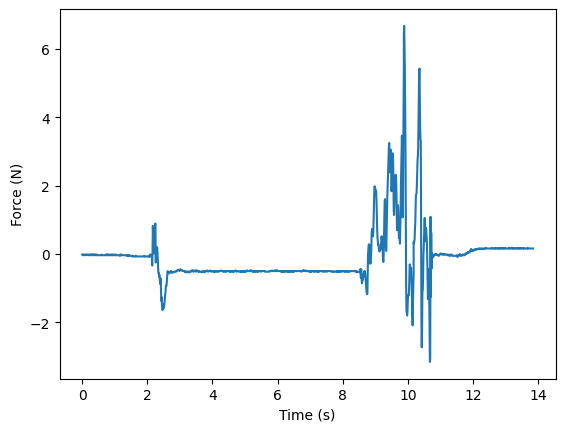

In [ ]:
data_0_50_1 = pd.read_csv('sensor_ Force --remote_ 1 --\'Run1.csv', sep=';')
data_0_50_1 = data_0_50_1.rename(columns={'Time (s)':'Time (s)', 'Fᵧ (N)':'Force (N)'})
print(data_0_50_1)
plt.plot(data_0_50_1['Time (s)'], data_0_50_1['Force (N)'])
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.show()
# We want to measure the mass, which is the average over the time period where
# The function is approximately stable and nonzero.
# The spikes we see are from the difficulty and additional forces associated
# with adding and removing my the weights from the ioLab module.
# Time precision error of the ioLab is 0.01s

In [ ]:
# Setting an example for how we populate our dataframe. Populating the remainder:
df_averages_0 = pd.DataFrame(columns=['Trial 1', 'Trial 2', 'Trial 3'], index=[50,100,150])
start_window = 4
end_window = 7
df_averages_0.loc[50, 'Trial 1'] = abs(data_0_50_1[(data_0_50_1['Time (s)'] >= start_window)
& (data_0_50_1['Time (s)'] <= end_window)]['Force (N)'].mean())/(9.8) * 1000
print(df_averages_0)

      Trial 1 Trial 2 Trial 3
50   51.45012     NaN     NaN
100       NaN     NaN     NaN
150       NaN     NaN     NaN


In [ ]:
# Continuing the rest of the data population
data_0_50_2 = pd.read_csv('sensor_ Force --remote_ 1 --\'Run2.csv').rename(columns={'Time (s)':'Time (s)', 'Fᵧ (N)':'Force (N)'})
start_window = 6
end_window = 10
def meanGettingP0(data, colname, start, end):
  return abs(data[(data['Time (s)'] >= start)
& (data['Time (s)'] <= end)][colname].mean() - data[(data['Time (s)'] >= 0)
& (data['Time (s)'] <= 2)][colname].mean())/(9.8) * 1000
def stdGettingP0(data, colname, start, end):
  return data[(data['Time (s)'] >= start)
& (data['Time (s)'] <= end)][colname].std()/(9.8) * 1000
df_averages_0.loc[50, 'Trial 2'] = meanGettingP0(data_0_50_2, 'Force (N)', 6, 10)
data_0_50_3 = pd.read_csv('sensor_ Force --remote_ 1 --\'Run3.csv', sep=";").rename(columns={'Time (s)':'Time (s)', 'Fᵧ (N)':'Force (N)'})
df_averages_0.loc[50, 'Trial 3'] = meanGettingP0(data_0_50_3, 'Force (N)', 5, 9)
data_0_100 = pd.read_csv('lab 7 p0--Mon Feb 23 2026--aquisition-stack-100g.csv',sep=';',header=0,names=['Time (s)', 'Run 1', 'Run 2', 'Run 3'])
df_averages_0.loc[100,'Trial 1'] = meanGettingP0(data_0_100, 'Run 1', 10, 14)
df_averages_0.loc[100,'Trial 2'] = meanGettingP0(data_0_100, 'Run 2', 10, 14)
df_averages_0.loc[100,'Trial 3'] = meanGettingP0(data_0_100, 'Run 3', 9, 13)

data_0_150 = pd.read_csv('lab 7 p0--Mon Feb 23 2026--aquisition-stack-150g.csv',sep=';',header=0,names=['Time (s)', 'Run 1', 'Run 2', 'Run 3'])
df_averages_0.loc[150,'Trial 1'] = meanGettingP0(data_0_150, 'Run 1', 6, 10)
df_averages_0.loc[150,'Trial 2'] = meanGettingP0(data_0_150, 'Run 2', 9, 13)
df_averages_0.loc[150,'Trial 3'] = meanGettingP0(data_0_150, 'Run 3', 8, 12)
print(df_averages_0)

df_stdevs_0 = pd.DataFrame(columns=['Trial 1', 'Trial 2', 'Trial 3'], index=[50,100,150])
df_stdevs_0.loc[50, 'Trial 1'] = stdGettingP0(data_0_50_1, 'Force (N)', 4, 7)
df_stdevs_0.loc[50, 'Trial 2'] = stdGettingP0(data_0_50_2, 'Force (N)', 6, 10)
df_stdevs_0.loc[50, 'Trial 3'] = stdGettingP0(data_0_50_3, 'Force (N)', 5, 9)
df_stdevs_0.loc[100,'Trial 1'] = stdGettingP0(data_0_100, 'Run 1', 10, 14)
df_stdevs_0.loc[100,'Trial 2'] = stdGettingP0(data_0_100, 'Run 2', 10, 14)
df_stdevs_0.loc[100,'Trial 3'] = stdGettingP0(data_0_100, 'Run 3', 9, 13)
df_stdevs_0.loc[150,'Trial 1'] = stdGettingP0(data_0_150, 'Run 1', 6, 10)
df_stdevs_0.loc[150,'Trial 2'] = stdGettingP0(data_0_150, 'Run 2', 9, 13)
df_stdevs_0.loc[150,'Trial 3'] = stdGettingP0(data_0_150, 'Run 3', 8, 12)
print(df_stdevs_0)

finals = [f'{df_averages_0.loc[x].mean():.3f} +- {np.sqrt((df_stdevs_0.loc[x]**2).sum()):.3 }' for x in [50, 100, 150]]
print(finals)

        Trial 1     Trial 2     Trial 3
50     51.45012     50.3454    48.19664
100   95.496459     99.5701  100.383539
150  145.670648  149.382237  148.521106
      Trial 1   Trial 2   Trial 3
50   1.017249  0.868451    0.9423
100  1.123619  1.553707  1.250059
150  1.171145  1.093667  1.003164
['49.997 +- 1.636', '98.483 +- 2.289', '147.858 +- 1.891']


# 2/18/2026
## Part 1: Procedure on Hooke’s law (0 degrees case)
### Measurement Procedure:
1. Calibrate the ioLab.
2. Record the force and wheel position with each measurement.
3. Hit record, then slowly pull the ioLab to stretch the spring.
4. Pull the apparatus until it reaches a spring stretch of 15 cm. Then slowly return it back to the start position.
5. Stop the recording.
6. Repeat for a total of 5 trials.
### Things to keep in mind while recording:
- Ensure the wheels keep in contact with the surface during the entirety of the measurement.
- Pull the ioLab smoothly with minimal jerkiness.


                            OLS Regression Results                            
Dep. Variable:               F: Run 3   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.459e+06
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:54:41   Log-Likelihood:                 9719.6
No. Observations:                2999   AIC:                        -1.944e+04
Df Residuals:                    2997   BIC:                        -1.942e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4365      0.000   -957.547      0.0

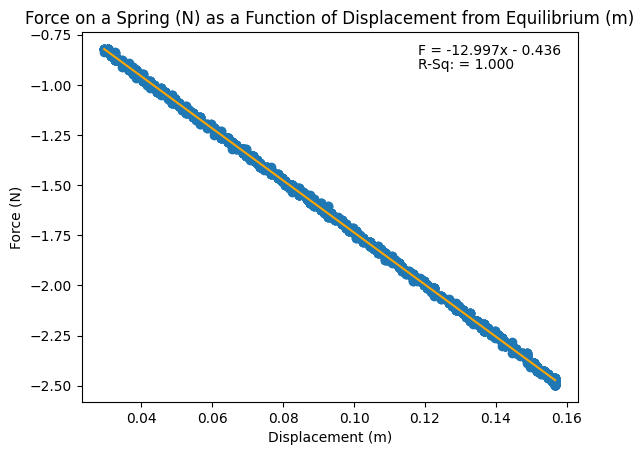

k: 12.997317933407281
k_err: 0.004468717373365354


/tmp/ipykernel_163/205983171.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'k_err: {results_2.bse[1]}')


In [ ]:
# data for part 1
data_2 = pd.read_csv('lab 7 p1--Mon Feb 23 2026--aquisition-stack.csv',sep=';',header=0, names=['Time (s)','F: Run 1','F: Run 2',
                                                                                               'F: Run 3','F: Run 4','F: Run 5',
                                                                                               'W: Run 1','W: Run 2','W: Run 3',
                                                                                               'W: Run 4','W: Run 5'])

# Run 3 unloading visually seems to be the most realistic data.
def p1_relevant_data_puller(run, start, stop):
  return data_2[(data_2['Time (s)'] >= start) & (data_2['Time (s)'] <= stop)][['Time (s)', 'F: Run '+str(run), 'W: Run '+str(run)]]
df_2 = p1_relevant_data_puller(3, 31, 61)
x_2 = df_2['W: Run 3']
y_2 = df_2['F: Run 3']
x_2 = sm.add_constant(x_2)
model_2 = sm.OLS(y_2,x_2)
results_2 = model_2.fit()
print(results_2.summary())
plt.scatter(df_2['W: Run 3'], y_2)
plt.plot(df_2['W: Run 3'], results_2.predict(), color='orange')
plt.title('Force on a Spring (N) as a Function of Displacement from Equilibrium (m)')
plt.xlabel('Displacement (m)')
plt.ylabel('Force (N)')
plt.text(0.118,-0.85,f'F = {results_2.params.iloc[1]:.3f}x - {-results_2.params.iloc[0]:.3f}')
plt.text(0.118,-0.92,f'R-Sq: = {results_2.rsquared:.3f}')
plt.show()
k_2 = results_2.params.iloc[1]
print(f'k: {-k_2}')
print(f'k_err: {results_2.bse[1]}')

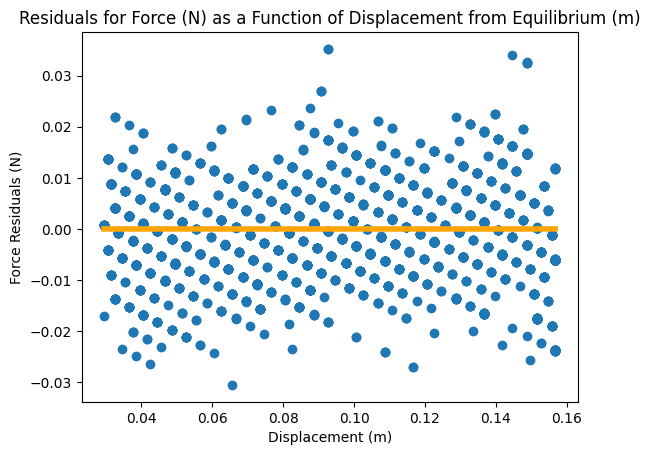

                            OLS Regression Results                            
Dep. Variable:               F: Run 3   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                -1.238e-12
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               1.00
Time:                        23:54:41   Log-Likelihood:                 9719.6
No. Observations:                2999   AIC:                        -1.944e+04
Df Residuals:                    2997   BIC:                        -1.942e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.145e-15      0.000  -2.51e-12      1.0

In [ ]:
residuals_2 = y_2 - results_2.predict()
plt.scatter(df_2['W: Run 3'], residuals_2)
plt.title('Residuals for Force (N) as a Function of Displacement from Equilibrium (m)')
plt.xlabel('Displacement (m)')
plt.ylabel('Force Residuals (N)')
model_2_residuals = sm.OLS(residuals_2,x_2)
results_2_residuals = model_2_residuals.fit()
plt.plot(df_2['W: Run 3'], results_2_residuals.predict(), color = 'orange', lw=4)
plt.show()
print(results_2_residuals.summary())

# 2/18/2026
## Part 2: Procedure on Harmonic Oscillation (90 degrees case)
### Measurement Procedure:
1. Attach a wooden dowel to the lab stand and connect the spring to it. Place the ioLab on the other end of the spring.
2. Select the acceleration and force measurements on the ioLab. Calibrate as needed.
3. Pull the ioLab downwards to reach a displacement of 5 cm. Release and hit record after a stable oscillation achieved.
4. Let the apparatus oscillate for 15 periods. Then stop the recording.
5. Repeat for a total of 5 trials.
### Things to keep in mind while recording:
- When releasing, ensure no initial velocity is imparted on the ioLab.
- Make sure the ioLab is pulled vertically to the table as best as possible.

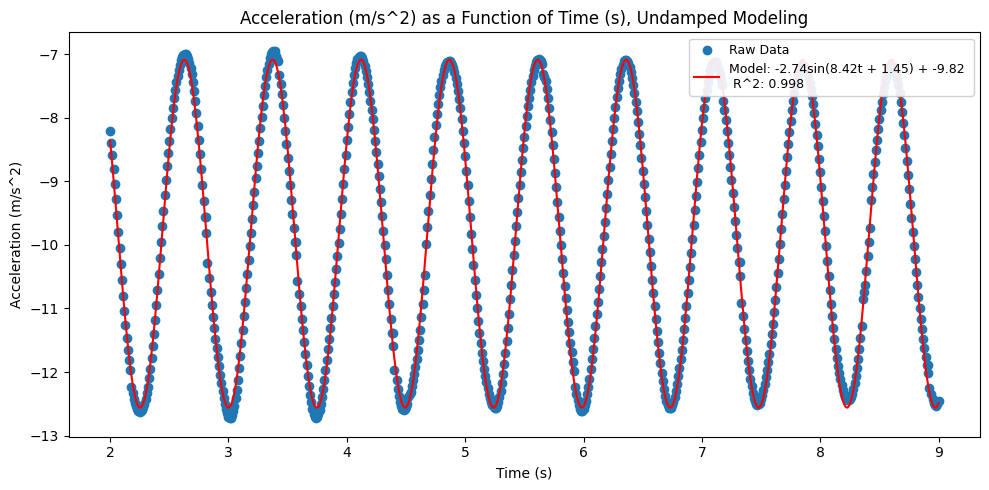

model: -2.74sin(8.42t + 1.45) + -9.82
param 0: -2.737 \ 0.005 \ -818.528, \ 0.000 \ -2.746 \ -2.727
param 1: 8.416 \ 0.001 \ 14057.952, \ 0.000 \ 8.415 \ 8.418
param 2: 1.452 \ 0.005 \ 416.716, \ 0.000 \ 1.443 \ 1.462
param 3: -9.823 \ 0.003 \ -4162.459, \ 0.000 \ -9.830 \ -9.817


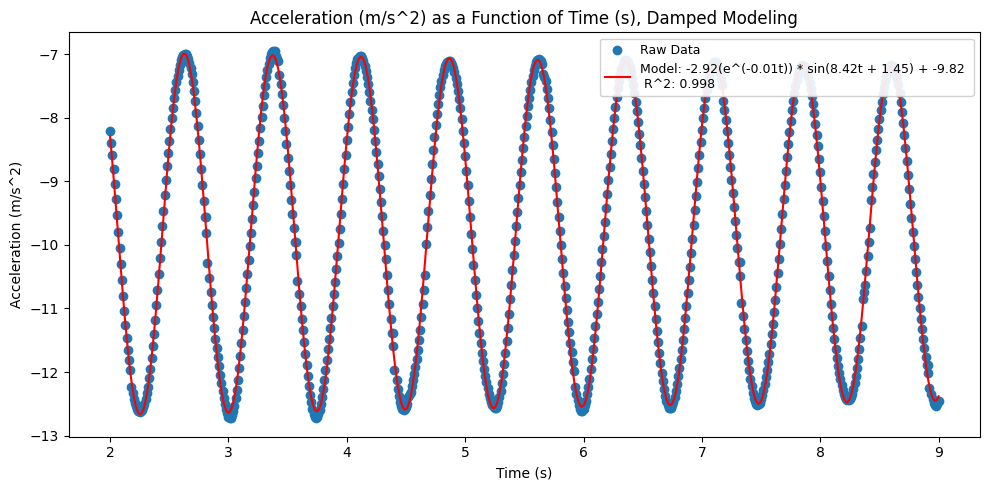

model: -2.92(e^(-0.01t)) * sin(8.42t + 1.45) + -9.82
param 0: -2.916 \ 0.013 \ -329.463, \ 0.000 \ -2.941 \ -2.892
param 1: 8.417 \ 0.001 \ 16324.121, \ 0.000 \ 8.415 \ 8.418
param 2: 1.451 \ 0.004 \ 490.937, \ 0.000 \ 1.443 \ 1.459
param 3: -9.822 \ 0.003 \ -4830.510, \ 0.000 \ -9.828 \ -9.817
param 4: 0.012 \ 0.001 \ 22.072, \ 0.002 \ 0.010 \ 0.013
p value: 0.002046314025052266
r2 value for undamped: 0.997923978510196
r2 value for damped: 0.9984617563407702


In [ ]:
# data for part 2
data_3 = pd.read_csv('lab 7 p2--Mon Feb 23 2026--aquisition-stack.csv', sep=';', header=0, names=['Time (s)','Ay: Run 1','Ay: Run 2',
                                                                                               'Ay: Run 3','Ay: Run 4','Ay: Run 5',
                                                                                               'F: Run 1','F: Run 2','F: Run 3',
                                                                                               'F: Run 4','F: Run 5'])
# visually run 4 appeared strongest
def p2_relevant_data_puller(run, start, stop):
  return data_3[(data_3['Time (s)'] >= start) & (data_3['Time (s)'] <= stop)][['Time (s)', 'Ay: Run '+str(run), 'F: Run '+str(run)]]
df_3 = p2_relevant_data_puller(4, 2, 9)
def sine_model(x, A, omega, phi, D):
  return A * np.sin(omega * x + phi) + D
x_3 = df_3['Time (s)']
y_3 = df_3['Ay: Run 4']

initial_guess_2 = [7, 7.9, 3, -10]
params_sin, params_sin_cov = curve_fit(sine_model, x_3, y_3, p0=initial_guess_2)
y_pred_3 = params_sin[0] * np.sin(params_sin[1] * x_3 + params_sin[2]) + params_sin[3]
plt.figure(figsize=(10,5))
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration (m/s^2) as a Function of Time (s), Undamped Modeling')
plt.scatter(x_3, y_3, label="Raw Data")
plt.plot(x_3, y_pred_3, color='red', label=f"Model: {params_sin[0]:.2f}sin({params_sin[1]:.2f}t + {params_sin[2]:.2f}) + {params_sin[3]:.2f} \n R^2: {r2_score(y_3, y_pred_3):.3f}")
plt.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()
print(f'model: {params_sin[0]:.2f}sin({params_sin[1]:.2f}t + {params_sin[2]:.2f}) + {params_sin[3]:.2f}')

t_val = sp.t.ppf(1 - 0.05/2, 697)
for i in range(len(params_sin)): # Corrected line: removed parentheses around 'i in range'
  t, p = sp.ttest_ind_from_stats(mean1=params_sin[i], std1=np.sqrt(params_sin_cov[i][i]), nobs1=2, mean2=0, std2=0, nobs2=2)
  sterr = np.sqrt(params_sin_cov[i][i])
  print(f'param {i}: {params_sin[i]:.3f} \\ {sterr:.3f} \\ {t:.3f}, \\ {p:.3f} \\ {params_sin[i] - sterr*t_val:.3f} \\ {params_sin[i] + sterr*t_val:.3f}')


def damped_model(x, A, omega, phi, D, gamma):
  return A * np.exp(-gamma * x) * np.sin(omega * x + phi) + D
initial_guess_2 = [7, 7.9, 3, -10, 0]
params_damped, params_damped_cov = curve_fit(damped_model, x_3, y_3, p0=initial_guess_2)
y_pred_4 = params_damped[0] * np.exp(-params_damped[4]*x_3) * np.sin(params_damped[1] * x_3 + params_damped[2]) + params_damped[3]
plt.figure(figsize=(10,5))
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration (m/s^2) as a Function of Time (s), Damped Modeling')
plt.scatter(x_3, y_3, label="Raw Data")
plt.plot(x_3, y_pred_4, color='red', label=f'Model: {params_damped[0]:.2f}(e^(-{params_damped[4]:.2f}t)) * sin({params_damped[1]:.2f}t + {params_damped[2]:.2f}) + {params_damped[3]:.2f} \n R^2: {r2_score(y_3, y_pred_4):.3f}')
plt.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()
print(f'model: {params_damped[0]:.2f}(e^(-{params_damped[4]:.2f}t)) * sin({params_damped[1]:.2f}t + {params_damped[2]:.2f}) + {params_damped[3]:.2f}')
t_val = sp.t.ppf(1 - 0.05/2, 696)
for i in range(len(params_damped)):
  t, p = sp.ttest_ind_from_stats(mean1=params_damped[i], std1=np.sqrt(params_damped_cov[i][i]), nobs1=2, mean2=0, std2=0, nobs2=2)
  sterr = np.sqrt(params_damped_cov[i][i])
  print(f'param {i}: {params_damped[i]:.3f} \\ {sterr:.3f} \\ {t:.3f}, \\ {p:.3f} \\ {params_damped[i] - sterr*t_val:.3f} \\ {params_damped[i] + sterr*t_val:.3f}')

# is gamma statistically significant?
t_gamma, p_gamma = sp.ttest_ind_from_stats(mean1=params_damped[4], std1=np.sqrt(params_damped_cov[4][4]), nobs1=2, mean2=0, std2=0, nobs2=2)
print(f'p value: {p_gamma}')

# relative quality of the models
print(f'r2 value for undamped: {r2_score(y_3, y_pred_3)}')
print(f'r2 value for damped: {r2_score(y_3, y_pred_4)}')


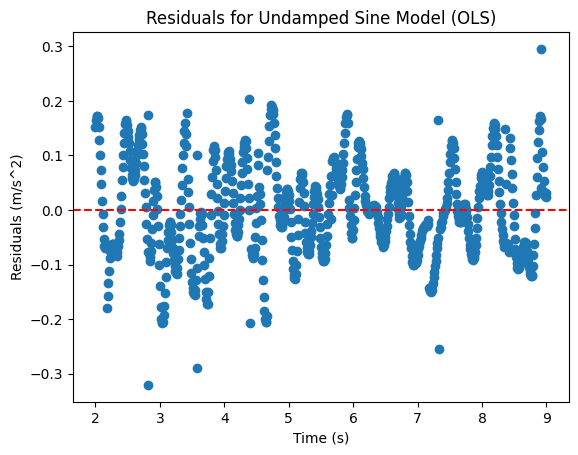

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &    Ay: Run 4     & \textbf{  R-squared:         } &     0.998   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.998   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } & 3.360e+05   \\
\textbf{Date:}             & Thu, 05 Mar 2026 & \textbf{  Prob (F-statistic):} &     0.00    \\
\textbf{Time:}             &     23:54:43     & \textbf{  Log-Likelihood:    } &    708.92   \\
\textbf{No. Observations:} &         701      & \textbf{  AIC:               } &    -1414.   \\
\textbf{Df Residuals:}     &         699      & \textbf{  BIC:               } &    -1405.   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                  & \textbf{coef} & \te

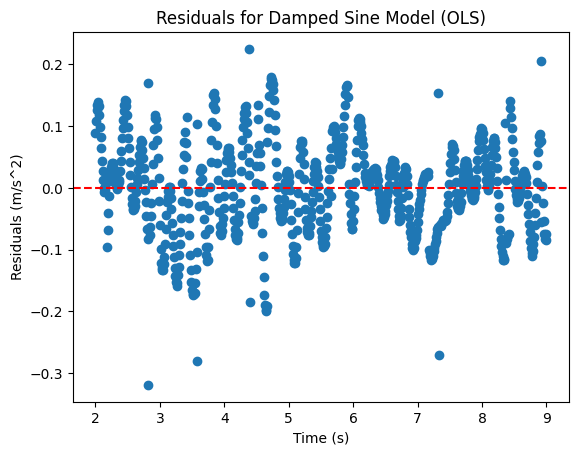

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &    Ay: Run 4     & \textbf{  R-squared:         } &     0.998   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.998   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } & 4.537e+05   \\
\textbf{Date:}             & Thu, 05 Mar 2026 & \textbf{  Prob (F-statistic):} &     0.00    \\
\textbf{Time:}             &     23:54:43     & \textbf{  Log-Likelihood:    } &    814.01   \\
\textbf{No. Observations:} &         701      & \textbf{  AIC:               } &    -1624.   \\
\textbf{Df Residuals:}     &         699      & \textbf{  BIC:               } &    -1615.   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                  & \textbf{coef} & \te

In [ ]:
X_undamped = sm.add_constant(y_pred_3)
model_undamped = sm.OLS(y_3, X_undamped).fit()

plt.scatter(x_3, model_undamped.resid)
plt.title('Residuals for Undamped Sine Model (OLS)')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.axhline(0, color='red', linestyle='--')
plt.show()
print(model_undamped.summary().as_latex())

X_damped = sm.add_constant(y_pred_4)
model_damped = sm.OLS(y_3, X_damped).fit()

plt.scatter(x_3, model_damped.resid)
plt.title('Residuals for Damped Sine Model (OLS)')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.axhline(0, color='red', linestyle='--')
plt.show()
print(model_damped.summary().as_latex())

So we find that, although small, $\gamma$ is statistically significant (cannot be taken to agree with 0) so we conclude this is in the regime of damped oscillation. We also see that the $R^2$ value is slightly higher for damped oscilation; this, however, is to be expected regardless of regime as allowing for an additional parameter will necessarily lead to stronger fitting (if it would not, the additional parameter would simply equal 0).

# 2/18/2026
## Part 3: Procedure o Harmonic Oscillation (60 degrees case)
### Measurement Procedure:
1. Slant the board at a 60 degree angle using the stand at the lab bench. Record this angle.
2. Attach the spring and ioLab to the top of the board. Select acceleration, force, and wheel position to record.
3. Pull the ioLab far enough so that it will oscillate at least 10 periods before stopping (a line is marked at 10.5 cm of displacement).
4. Start the recording and release the ioLab.
5. After it stops oscillating (at least 10 periods later), stop the recording.
6. Repeat for a total of 5 trials.
### Things to keep in mind while recording:
- Release the ioLab so that its wheels are in line with the spring.
- Make sure the angle is not too steep so that the wheels stay in contact and roll without slipping during the entirety of the trials.
- Do not pull the ioLab too far so that it does not fully compress the spring on the first oscillation, while pulling far enough so that it can oscillate at least 10 times before stopping.

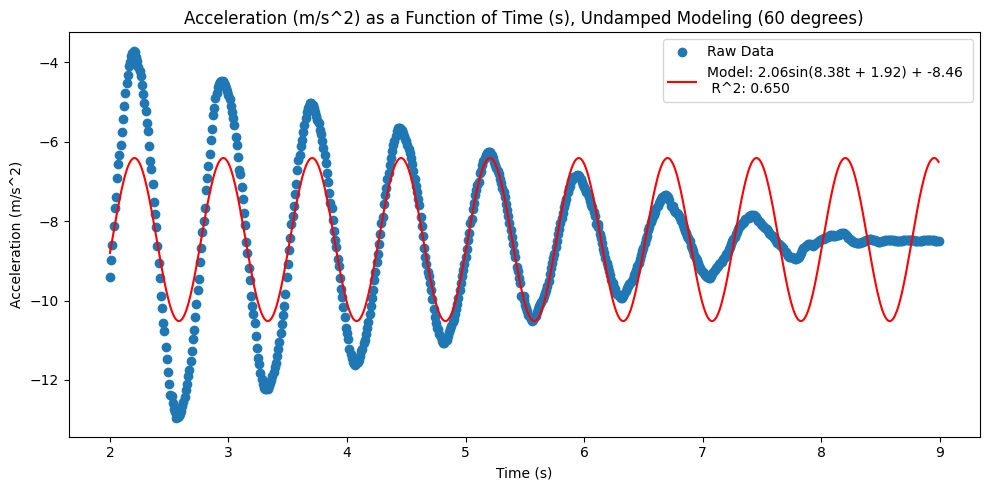

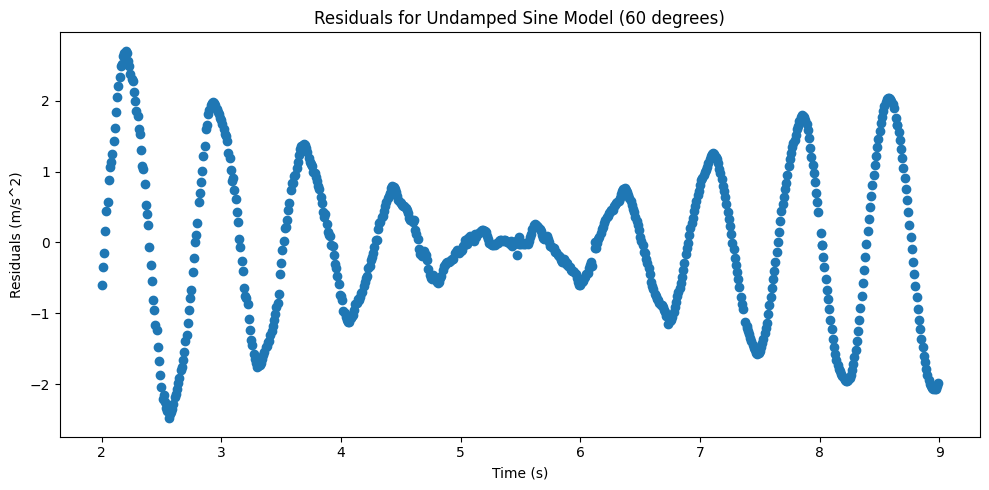

model: 2.06sin(8.38t + 1.92) + -8.46
param 0: 2.056 \ 0.057 \ 50.875, \ 0.000 \ 1.944 \ 2.168
param 1: 8.383 \ 0.014 \ 858.613, \ 0.000 \ 8.356 \ 8.410
param 2: 1.918 \ 0.080 \ 33.733, \ 0.001 \ 1.760 \ 2.076
param 3: -8.463 \ 0.040 \ -295.662, \ 0.000 \ -8.542 \ -8.383


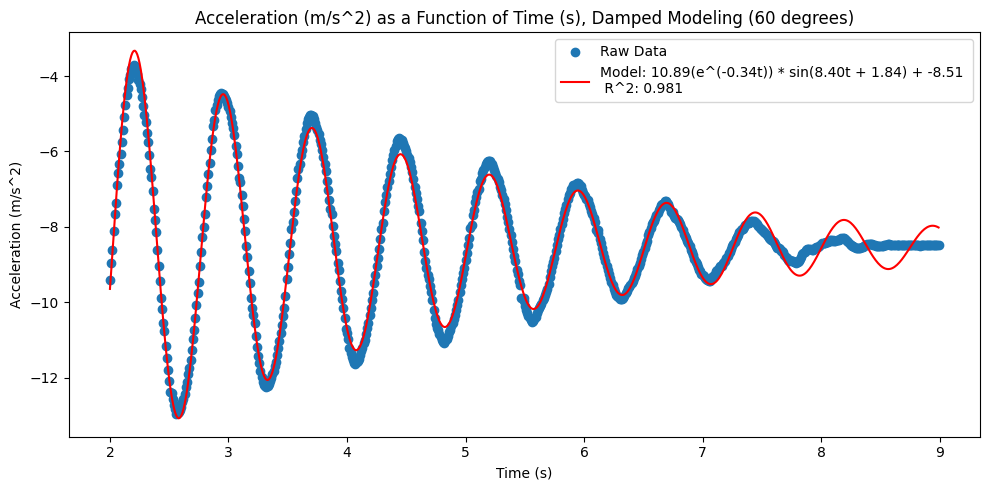

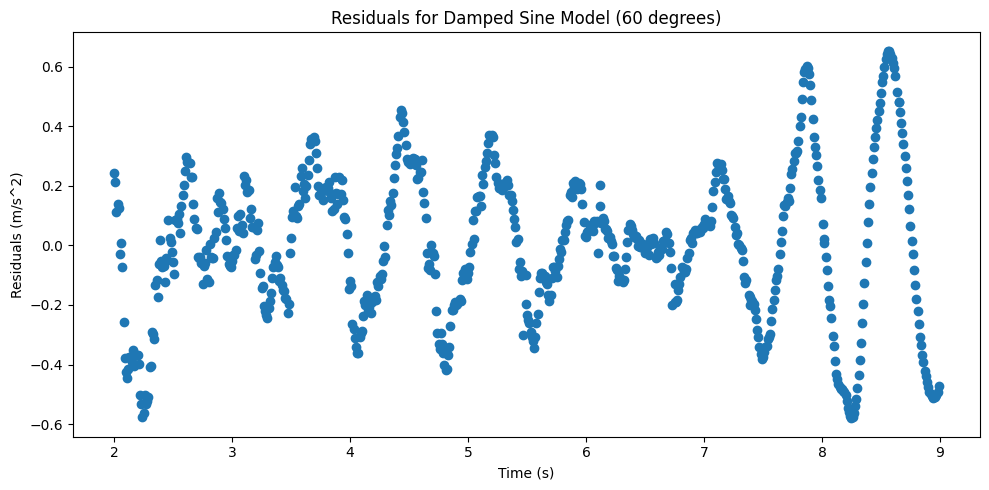

model: 10.89(e^(-0.34t)) * sin(8.40t + 1.84) + -8.51
param 0: 10.894 \ 0.162 \ 94.953, \ 0.000 \ 10.575 \ 11.213
param 1: 8.399 \ 0.004 \ 3023.271, \ 0.000 \ 8.391 \ 8.407
param 2: 1.843 \ 0.014 \ 182.247, \ 0.000 \ 1.815 \ 1.871
param 3: -8.510 \ 0.010 \ -1262.767, \ 0.000 \ -8.529 \ -8.491
param 4: 0.336 \ 0.004 \ 118.261, \ 0.000 \ 0.328 \ 0.344
p value: 7.149376565283386e-05


In [ ]:
data_4 = pd.read_csv('lab7 p3--Mon Feb 23 2026--aquisition-stack.csv', sep=';', header=0, names=['Time (s)','Ay: Run 1','Ay: Run 2',
                                                                                               'Ay: Run 3','Ay: Run 4','Ay: Run 5',
                                                                                               'F: Run 1','F: Run 2','F: Run 3',
                                                                                               'F: Run 4','F: Run 5','W: Run 1','W: Run 2','W: Run 3',
                                                                                               'W: Run 4','W: Run 5'])
# visually run 4 appeared strongest
def p3_relevant_data_puller(run, start, stop):
  return data_4[(data_4['Time (s)'] >= start) & (data_4['Time (s)'] <= stop)][['Time (s)', 'Ay: Run '+str(run), 'F: Run '+str(run)]]
df_4 = p3_relevant_data_puller(5, 2, 9)

x_4 = df_4['Time (s)']
y_4 = df_4['Ay: Run 5']

initial_guess_4 = [4, 8.5, 2, -8]
params_sin_2, params_sin_2_cov = curve_fit(sine_model, x_4, y_4, p0=initial_guess_4)
y_pred_5 = params_sin_2[0] * np.sin(params_sin_2[1] * x_4 + params_sin_2[2]) + params_sin_2[3]
plt.figure(figsize=(10,5))
plt.scatter(x_4, y_4, label="Raw Data")
plt.plot(x_4, y_pred_5, color='red', label=f"Model: {params_sin_2[0]:.2f}sin({params_sin_2[1]:.2f}t + {params_sin_2[2]:.2f}) + {params_sin_2[3]:.2f} \n R^2: {r2_score(y_4, y_pred_5):.3f}")
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration (m/s^2) as a Function of Time (s), Undamped Modeling (60 degrees)')
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,5))
plt.scatter(x_4, y_4 - y_pred_5)
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.title('Residuals for Undamped Sine Model (60 degrees)')
plt.tight_layout()
plt.show()
print(f'model: {params_sin_2[0]:.2f}sin({params_sin_2[1]:.2f}t + {params_sin_2[2]:.2f}) + {params_sin_2[3]:.2f}')

t_val_undamped_p3 = sp.t.ppf(1 - 0.05/2, 696)
for i in range(len(params_sin_2)):
  t_param, p_param = sp.ttest_ind_from_stats(mean1=params_sin_2[i], std1=np.sqrt(params_sin_2_cov[i][i]), nobs1=2, mean2=0, std2=0, nobs2=2)
  sterr_param = np.sqrt(params_sin_2_cov[i][i])
  print(f'param {i}: {params_sin_2[i]:.3f} \\ {sterr_param:.3f} \\ {t_param:.3f}, \\ {p_param:.3f} \\ {params_sin_2[i] - sterr_param*t_val_undamped_p3:.3f} \\ {params_sin_2[i] + sterr_param*t_val_undamped_p3:.3f}')


initial_guess_5 = [10, 8.5, 2, -8, 0]
params_damped_4, params_damped_4_cov = curve_fit(damped_model, x_4, y_4, p0=initial_guess_5)
y_pred_6 = params_damped_4[0] * np.exp(-params_damped_4[4]*x_4) * np.sin(params_damped_4[1] * x_4 + params_damped_4[2]) + params_damped_4[3]
plt.figure(figsize=(10,5))
plt.scatter(x_4, y_4, label="Raw Data")
plt.plot(x_4, y_pred_6, color='red', label=f'Model: {params_damped_4[0]:.2f}(e^(-{params_damped_4[4]:.2f}t)) * sin({params_damped_4[1]:.2f}t + {params_damped_4[2]:.2f}) + {params_damped_4[3]:.2f} \n R^2: {r2_score(y_4, y_pred_6):.3f}')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration (m/s^2) as a Function of Time (s), Damped Modeling (60 degrees)')
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,5))
plt.scatter(x_4, y_4 - y_pred_6)
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.title('Residuals for Damped Sine Model (60 degrees)')
plt.tight_layout()
plt.show()
print(f'model: {params_damped_4[0]:.2f}(e^(-{params_damped_4[4]:.2f}t)) * sin({params_damped_4[1]:.2f}t + {params_damped_4[2]:.2f}) + {params_damped_4[3]:.2f}')

t_val_damped_p3 = sp.t.ppf(1 - 0.05/2, 695)
for i in range(len(params_damped_4)):
  t_param, p_param = sp.ttest_ind_from_stats(mean1=params_damped_4[i], std1=np.sqrt(params_damped_4_cov[i][i]), nobs1=2, mean2=0, std2=0, nobs2=2)
  sterr_param = np.sqrt(params_damped_4_cov[i][i])
  print(f'param {i}: {params_damped_4[i]:.3f} \\ {sterr_param:.3f} \\ {t_param:.3f}, \\ {p_param:.3f} \\ {params_damped_4[i] - sterr_param*t_val_damped_p3:.3f} \\ {params_damped_4[i] + sterr_param*t_val_damped_p3:.3f}')

# is gamma statistically significant?
t_gamma, p_gamma = sp.ttest_ind_from_stats(mean1=params_damped_4[4], std1=np.sqrt(params_damped_4_cov[4][4]), nobs1=2, mean2=0, std2=0, nobs2=2)
print(f'p value: {p_gamma}')

It is thus clear that $\gamma$ is statistically significant and we are in a regime of underdamped oscillations. It is also clear that the residual plot for the underdamped model shows more random scatter than that of an undamped model, but it's lowkey still got problems

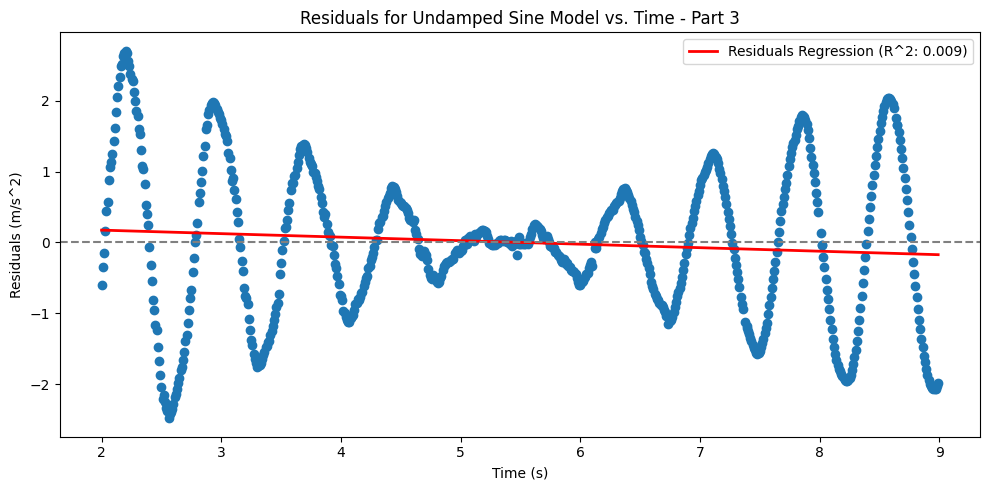

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared:         } &     0.009   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.007   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     6.227   \\
\textbf{Date:}             & Fri, 06 Mar 2026 & \textbf{  Prob (F-statistic):} &   0.0128    \\
\textbf{Time:}             &     00:21:43     & \textbf{  Log-Likelihood:    } &   -1035.2   \\
\textbf{No. Observations:} &         700      & \textbf{  AIC:               } &     2074.   \\
\textbf{Df Residuals:}     &         698      & \textbf{  BIC:               } &     2084.   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                  & \textbf{coef} & \te

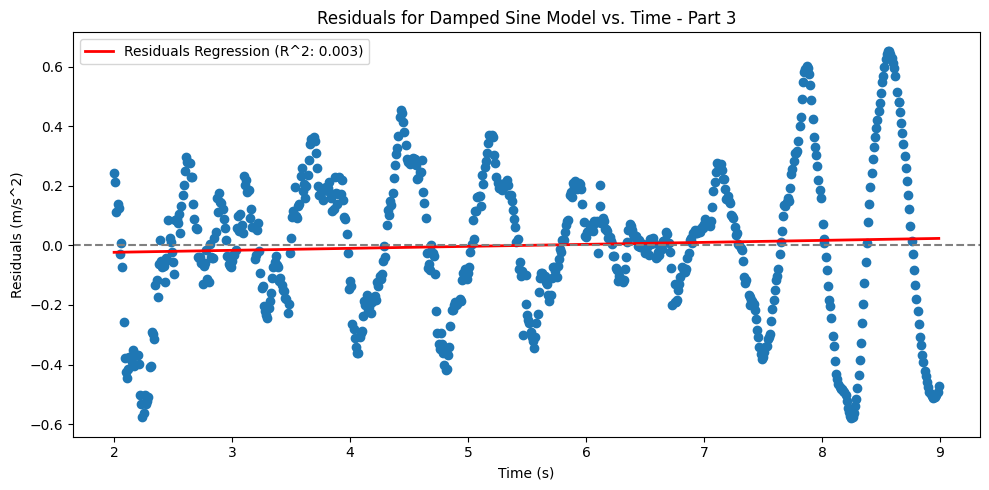

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared:         } &     0.003   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.001   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     2.027   \\
\textbf{Date:}             & Fri, 06 Mar 2026 & \textbf{  Prob (F-statistic):} &    0.155    \\
\textbf{Time:}             &     00:21:43     & \textbf{  Log-Likelihood:    } &   -23.542   \\
\textbf{No. Observations:} &         700      & \textbf{  AIC:               } &     51.08   \\
\textbf{Df Residuals:}     &         698      & \textbf{  BIC:               } &     60.19   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                  & \textbf{coef} & \te

In [ ]:
undamped_residuals_p3 = y_4 - y_pred_5

# OLS Regression of undamped residuals against time
x_4_const = sm.add_constant(x_4)
model_undamped_residuals_p3 = sm.OLS(undamped_residuals_p3, x_4_const).fit()

plt.figure(figsize=(10,5))
plt.scatter(x_4, undamped_residuals_p3)
plt.plot(x_4, model_undamped_residuals_p3.predict(x_4_const), color = 'red', lw=2, label=f'Residuals Regression (R^2: {model_undamped_residuals_p3.rsquared:.3f})')
plt.title('Residuals for Undamped Sine Model vs. Time - Part 3')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.axhline(0, color='grey', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()
print(model_undamped_residuals_p3.summary().as_latex())

damped_residuals_p3 = y_4 - y_pred_6

# OLS Regression of damped residuals against time
model_damped_residuals_p3 = sm.OLS(damped_residuals_p3, x_4_const).fit()

plt.figure(figsize=(10,5))
plt.scatter(x_4, damped_residuals_p3)
plt.plot(x_4, model_damped_residuals_p3.predict(x_4_const), color = 'red', lw=2, label=f'Residuals Regression (R^2: {model_damped_residuals_p3.rsquared:.3f})')
plt.title('Residuals for Damped Sine Model vs. Time - Part 3')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.axhline(0, color='grey', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()
print(model_damped_residuals_p3.summary().as_latex())

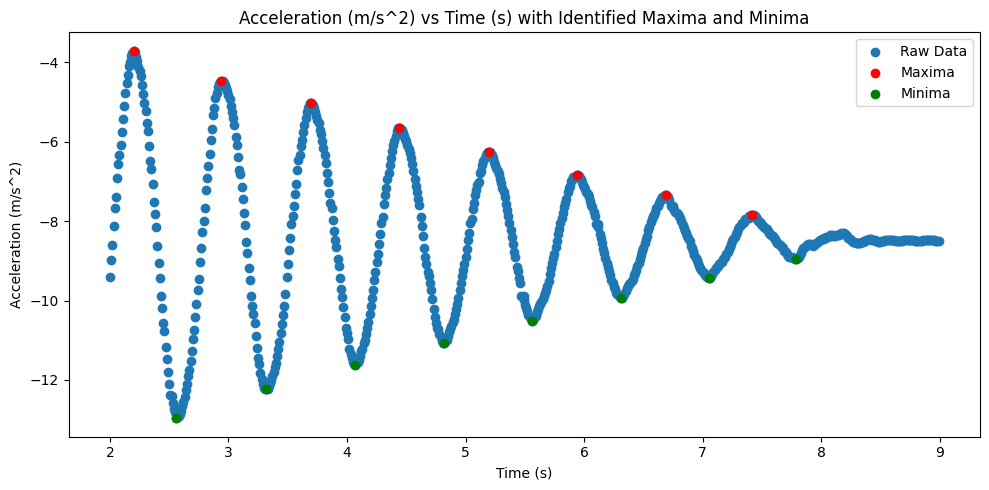

In [ ]:
# modeling velocity independent friction
period = np.pi / params_damped_4[1]
# x_4 starts with index 206
samples_per_period = period / (x_4[207] - x_4[206])
# take the maximum value per period
# prominence is included to help ease out the noisy collection at the end
indices, _ = find_peaks(y_4, distance=samples_per_period, prominence=0.3)
maxima_times = x_4.iloc[indices]
maxima = y_4.iloc[indices]
indices, _ = find_peaks(-y_4, distance=samples_per_period, prominence=0.3)
minima_times = x_4.iloc[indices]
minima = y_4.iloc[indices]
plt.figure(figsize=(10,5))
plt.scatter(x_4, y_4, label="Raw Data")
plt.scatter(maxima_times, maxima, c='red', label="Maxima")
plt.scatter(minima_times, minima, c='green', label="Minima")
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration (m/s^2) vs Time (s) with Identified Maxima and Minima')
plt.legend()
plt.tight_layout()
plt.show()

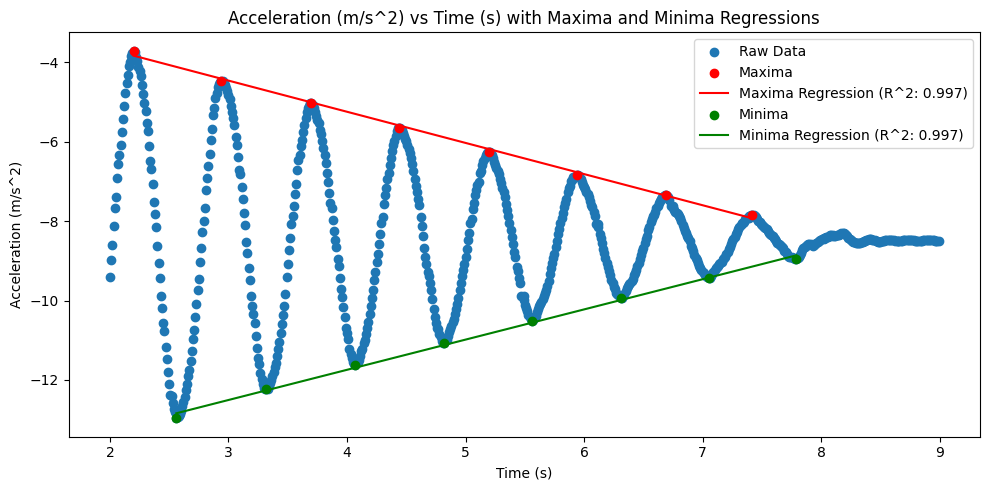

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &    Ay: Run 5     & \textbf{  R-squared:         } &     0.997   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.997   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     2254.   \\
\textbf{Date:}             & Fri, 06 Mar 2026 & \textbf{  Prob (F-statistic):} &  5.85e-09   \\
\textbf{Time:}             &     01:36:05     & \textbf{  Log-Likelihood:    } &    9.9927   \\
\textbf{No. Observations:} &           8      & \textbf{  AIC:               } &    -15.99   \\
\textbf{Df Residuals:}     &           6      & \textbf{  BIC:               } &    -15.83   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                  & \textbf{coef} & \te

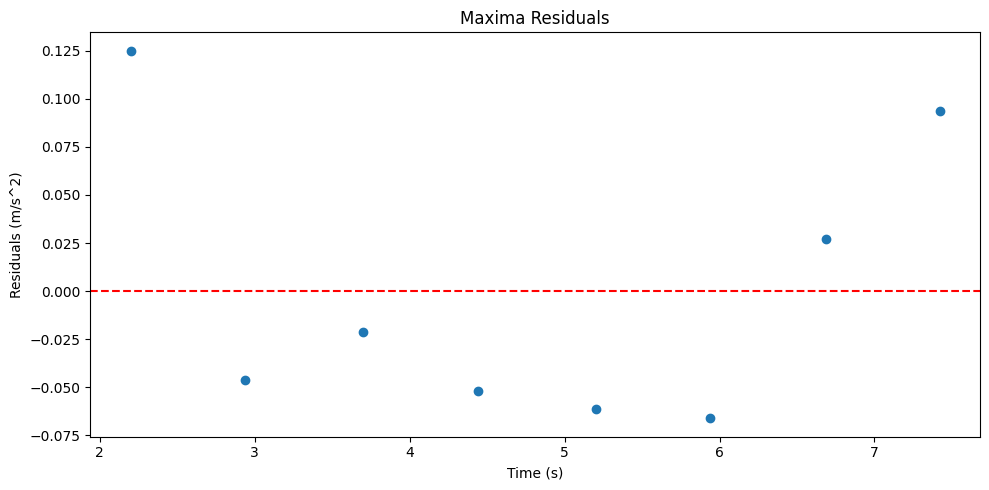

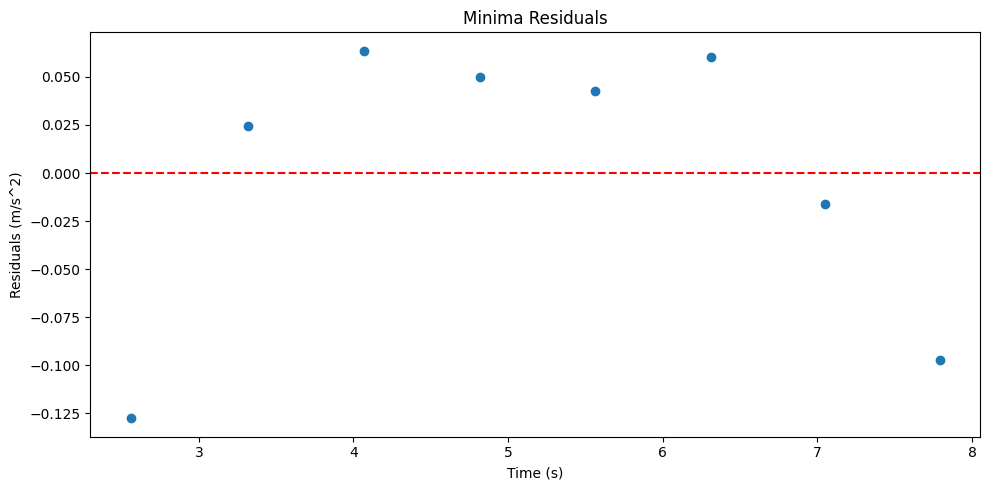

In [ ]:
x_maxima = maxima_times
x_maxima = sm.add_constant(x_maxima)
model_maxima = sm.OLS(maxima, x_maxima)
maxima_results = model_maxima.fit()

x_line_maxima = np.linspace(maxima_times.min(), maxima_times.max(), 100)
maxima_preds_line = maxima_results.predict(sm.add_constant(x_line_maxima))

x_minima = minima_times
x_minima = sm.add_constant(x_minima)
model_minima = sm.OLS(minima, x_minima)
minima_results = model_minima.fit()

x_line_minima = np.linspace(minima_times.min(), minima_times.max(), 100)
minima_preds_line = minima_results.predict(sm.add_constant(x_line_minima))

plt.figure(figsize=(10,5))
plt.scatter(x_4, y_4, label="Raw Data")
plt.scatter(maxima_times, maxima, c='red', label="Maxima")
plt.plot(x_line_maxima, maxima_preds_line, color='red', label=f"Maxima Regression (R^2: {maxima_results.rsquared:.3f})")
plt.scatter(minima_times, minima, c='green', label="Minima")
plt.plot(x_line_minima, minima_preds_line, color='green', label=f"Minima Regression (R^2: {minima_results.rsquared:.3f})")
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration (m/s^2) vs Time (s) with Maxima and Minima Regressions')
plt.legend()
plt.tight_layout()
plt.show()

print(maxima_results.summary().as_latex())
print(minima_results.summary().as_latex())

plt.figure(figsize=(10,5))
plt.scatter(maxima_times, maxima - maxima_results.predict(x_maxima))
plt.title('Maxima Residuals')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(minima_times, minima - minima_results.predict(x_minima))
plt.title('Minima Residuals')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m/s^2)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()